In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

import jax
import jax.numpy as jnp
import equinox as eqx
import jax.tree_util as jtu
import optax

from darnax.modules.conv.conv import Conv2D, Conv2DRecurrentDiscrete
from darnax.modules.conv.pooling import GlobalUnpooling, GlobalMajorityPooling
from darnax.modules.fully_connected import FullyConnected, FrozenRescaledFullyConnected
from darnax.modules.recurrent import RecurrentDiscrete
from darnax.modules.input_output import OutputLayer
from darnax.layer_maps.sparse import LayerMap
from darnax.states.sequential import SequentialState
from darnax.orchestrators.sequential import SequentialOrchestrator
from darnax.datasets.classification.cifar10 import Cifar10


In [14]:
# ── Dataset ────────────────────────────────────────────────────────────
data = Cifar10(batch_size=32, linear_projection=None, label_mode="pm1", x_transform="identity")
key = jax.random.PRNGKey(0)
key, data_key = jax.random.split(key)
data.build(key=data_key)

x, y = next(iter(data))
if x.ndim == 2:
    x = x.reshape(x.shape[0], 32, 32, 3)
x = (x - x.mean()) / x.std()
print(f"x: {x.shape}  y: {y.shape}")

# ── Experiment images (we average over 3 single images) ───────────────
IMG_INDICES = [0, 2, 4]   # three images to average curves over
print("\nImages used:")
for i in IMG_INDICES:
    lbl = int(np.array(y[i]).argmax())
    print(f"  idx={i}  label={lbl}")

# ── Dynamics constants ─────────────────────────────────────────────────
N_WARMUP  = 1
N_CLAMPED = 5
N_FREE    = 5
MOMENTUM  = 0.5
MASK_PROB = 0.2

# ── Sweep grid ─────────────────────────────────────────────────────────
THRESHOLDS = [0.5, 1.0, 1.7, 2.5, 3.5]
LRS        = [0.02, 0.05, 0.1, 0.2, 0.5]
N_UPDATES  = 30    # number of Hebbian weight updates per memorization run

print(f"\nSweep: {len(THRESHOLDS)} thresholds × {len(LRS)} lrs = "
      f"{len(THRESHOLDS)*len(LRS)} combos")
print(f"N_UPDATES={N_UPDATES}, averaged over {len(IMG_INDICES)} images")


x: (32, 32, 32, 3)  y: (32, 10)

Images used:
  idx=0  label=3
  idx=2  label=5
  idx=4  label=2

Sweep: 5 thresholds × 5 lrs = 25 combos
N_UPDATES=30, averaged over 3 images


In [19]:
def build_model(
    seed: int,
    threshold: float = 1.7,
    mask_prob: float = None,
    momentum: float = None,
    in_channels: int = 3,
    spatial_size: int = 32,
    n_channels: int = 64,
    num_labels: int = 10,
    input_kernel_size: int = 7,
    recur_kernel_size: int = 7,
    weight_decay_conv: float = 0.0,
):
    if mask_prob is None:
        mask_prob = MASK_PROB
    if momentum is None:
        momentum = MOMENTUM

    keys = jax.random.split(jax.random.key(seed), 5)
    S = spatial_size
    layer_map = LayerMap.from_dict({
        1: {
            0: Conv2D(in_channels=in_channels, out_channels=n_channels,
                      kernel_size=input_kernel_size, threshold=threshold,
                      strength=1.0, key=keys[0], padding_mode="constant"),
            1: Conv2DRecurrentDiscrete(channels=n_channels, kernel_size=recur_kernel_size,
                                       groups=n_channels, j_d=0.9, threshold=threshold,
                                       padding_mode="constant", key=keys[1], lr=1.0, weight_decay = weight_decay_conv),
            2: GlobalUnpooling(strength=1.0, axis=(1, 2)),
        },
        2: {
            1: GlobalMajorityPooling(strength=1.0, axis=(1, 2)),
            2: RecurrentDiscrete(features=n_channels, j_d=0.9,
                                  threshold=threshold, key=keys[2]),
            3: FrozenRescaledFullyConnected(in_features=num_labels, out_features=n_channels,
                                             strength=1.0, threshold=0.0, key=keys[3]),
        },
        3: {
            2: FullyConnected(in_features=n_channels, out_features=num_labels,
                               strength=1.0, threshold=threshold, key=keys[4]),
            3: OutputLayer(),
        },
    })
    state = SequentialState([(S, S, in_channels), (S, S, n_channels), (n_channels,), (num_labels,)])
    orch  = SequentialOrchestrator(layers=layer_map, field_momentum=momentum, mask_prob=mask_prob)
    return state, orch


def build_optimizer(orch, lr: float):
    trainable = {(1, 0): "w_in", (1, 1): "j_conv", (2, 2): "j_fc", (3, 2): "w_out"}
    params, _ = eqx.partition(orch, eqx.is_inexact_array)
    labels = jtu.tree_map(lambda _: "frozen", params, is_leaf=eqx.is_array)
    def _label(tree, tag):
        return jtu.tree_map(lambda _: tag, tree, is_leaf=eqx.is_array)
    for (i, j), tag in trainable.items():
        labels = eqx.tree_at(lambda m, _i=i, _j=j: m.lmap[_i][_j], labels,
                              replace=_label(params.lmap[i][j], tag))
    transforms = {"frozen": optax.sgd(0.0)}
    transforms.update({tag: optax.sgd(lr) for tag in trainable.values()})
    optimizer = optax.multi_transform(transforms, labels)
    opt_state = optimizer.init(eqx.filter(orch, eqx.is_inexact_array))
    return optimizer, opt_state


def run_dynamics(orch, state, rng, n_warmup=None, n_clamped=None, n_free=None):
    if n_warmup  is None: n_warmup  = N_WARMUP
    if n_clamped is None: n_clamped = N_CLAMPED
    if n_free    is None: n_free    = N_FREE
    history = []
    for _ in range(n_warmup):
        state, rng = orch.step(state, rng=rng, filter_messages="inference")
        history.append(state)
    for _ in range(n_clamped):
        state, rng = orch.step(state, rng=rng, filter_messages="all")
        history.append(state)
    for _ in range(n_free):
        state, rng = orch.step(state, rng=rng, filter_messages="inference")
        history.append(state)
    return state, history


def apply_update(orch, state, rng, optimizer, opt_state):
    grads      = orch.backward(state, rng=rng)
    g_filt     = eqx.filter(grads, eqx.is_inexact_array)
    p_filt     = eqx.filter(orch,  eqx.is_inexact_array)
    updates, new_opt_state = optimizer.update(g_filt, opt_state, params=p_filt)
    return eqx.apply_updates(orch, updates), new_opt_state


In [20]:
def _cosine(v1, v2):
    """1 - cosine similarity between two flat vectors."""
    a, b = np.array(v1).ravel(), np.array(v2).ravel()
    return float(1.0 - np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))


def _hidden_stability(orch, state):
    """s·h margin at hidden FC layer (layer 2): s2 · (Pool(s1) + J·s2 + W_back·s3)."""
    s1, s2, s3 = state.states[1], state.states[2], state.states[3]
    h = (orch.lmap[2][1](s1) +
         orch.lmap[2][2](s2) +
         orch.lmap[2][3](s3))
    return float(jnp.mean(s2 * h))


def _clamped_free_dist(history, layer_idx):
    """Cosine distance between end-of-clamped and end-of-free states."""
    i_clamp = N_WARMUP + N_CLAMPED - 1
    i_free  = len(history) - 1
    return _cosine(history[i_clamp].states[layer_idx], history[i_free].states[layer_idx])


def _flip_rate(history, layer_idx):
    """Mean fraction of units that flip sign between consecutive dynamics steps."""
    acts = [np.array(h.states[layer_idx]).ravel() for h in history]
    if len(acts) < 2:
        return 0.0
    return float(np.mean([np.mean(np.sign(acts[t]) != np.sign(acts[t + 1]))
                           for t in range(len(acts) - 1)]))


def _wback_overlap(orch, state):
    """Cosine similarity between W_back(y) = FrozenRescaledFC output and s2.

    W_back maps label vector s3 → hidden space. We measure how aligned
    the result is with the actual hidden state s2.
    """
    s2 = np.array(state.states[2]).ravel()
    s3 = np.array(state.states[3]).ravel()
    wb_out = np.array(orch.lmap[2][3](state.states[3])).ravel()
    dot   = float(np.dot(s2, wb_out))
    norm  = float(np.linalg.norm(s2) * np.linalg.norm(wb_out) + 1e-8)
    return dot / norm


def _soft_margin(orch, state, x_in, y_in, rng):
    """Run free prediction and return soft margin for the true class."""
    rng, pred_rng = jax.random.split(rng)
    pred_st, _ = orch.predict(state, pred_rng)
    logits = np.array(pred_st.states[-1]).ravel()
    y_np   = np.array(y_in).ravel()
    tc     = int(np.argmax(y_np))
    others = np.concatenate([logits[:tc], logits[tc + 1:]])
    return float(logits[tc] - others.max()), rng


In [21]:
def run_memorization(
    x_img, y_img,
    threshold: float,
    lr: float,
    seed: int = 0,
    n_updates: int = None,
) -> dict:
    """Train on a single image for n_updates steps; record 5 metrics at every step.

    Returns
    -------
    dict with keys:
      'soft_margin'      : list[float]  len = n_updates + 1
      'hidden_stability' : list[float]
      'cf_dist'          : list[float]  (clamped-free cosine dist, layer 2)
      'flip_rate'        : list[float]  (layer 2)
      'wback_overlap'    : list[float]
    """
    if n_updates is None:
        n_updates = N_UPDATES

    st, orch = build_model(seed=seed, threshold=threshold)
    optimizer, opt_state = build_optimizer(orch, lr=lr)
    rng = jax.random.PRNGKey(seed)

    records = {k: [] for k in
               ["soft_margin", "hidden_stability", "cf_dist", "flip_rate", "wback_overlap"]}

    for step in range(n_updates + 1):
        # ── evaluate current weights ───────────────────────────────────
        s0  = st.init(x_img, y_img)
        rng, dyn_rng = jax.random.split(rng)
        sf, history  = run_dynamics(orch, s0, rng=dyn_rng)

        sm, rng = _soft_margin(orch, sf, x_img, y_img, rng)
        hs      = _hidden_stability(orch, sf)
        cd      = _clamped_free_dist(history, layer_idx=2)
        fr      = _flip_rate(history, layer_idx=2)
        wo      = _wback_overlap(orch, sf)

        records["soft_margin"].append(sm)
        records["hidden_stability"].append(hs)
        records["cf_dist"].append(cd)
        records["flip_rate"].append(fr)
        records["wback_overlap"].append(wo)

        # ── weight update (skip after last eval) ──────────────────────
        if step < n_updates:
            rng, upd_rng = jax.random.split(rng)
            orch, opt_state = apply_update(orch, sf, upd_rng, optimizer, opt_state)

    return records


def average_runs(runs: list[dict]) -> dict:
    """Average a list of metric dicts (same keys, same length lists) → mean + std."""
    keys   = runs[0].keys()
    n_runs = len(runs)
    out    = {}
    for k in keys:
        arr = np.array([r[k] for r in runs], dtype=float)  # (n_runs, n_steps)
        out[k] = {"mean": arr.mean(axis=0), "std": arr.std(axis=0)}
    return out


def sweep_memorization(
    thresholds: list = None,
    lrs: list = None,
    img_indices: list = None,
    x_data=None,
    y_data=None,
    n_updates: int = None,
    seed: int = 0,
    verbose: bool = True,
) -> dict:
    """Run memorization for every (threshold, lr) combination, averaged over img_indices.

    Returns
    -------
    sweep : dict  (thr, lr) → averaged metrics dict  (same as average_runs output)
    """
    if thresholds  is None: thresholds  = THRESHOLDS
    if lrs         is None: lrs         = LRS
    if img_indices is None: img_indices = IMG_INDICES
    if x_data      is None: x_data      = x
    if y_data      is None: y_data      = y
    if n_updates   is None: n_updates   = N_UPDATES

    sweep = {}
    for thr in thresholds:
        for lr in lrs:
            runs = [
                run_memorization(
                    x_data[i:i+1], y_data[i:i+1],
                    threshold=thr, lr=lr, seed=seed, n_updates=n_updates,
                )
                for i in img_indices
            ]
            sweep[(thr, lr)] = average_runs(runs)
        if verbose:
            print(f"  thr={thr:.2f} done")
    return sweep


In [22]:
print("Running memorization sweep ...")
sweep = sweep_memorization(verbose=True)
print("Done.")


Running memorization sweep ...
  thr=0.50 done
  thr=1.00 done
  thr=1.70 done
  thr=2.50 done
  thr=3.50 done
Done.


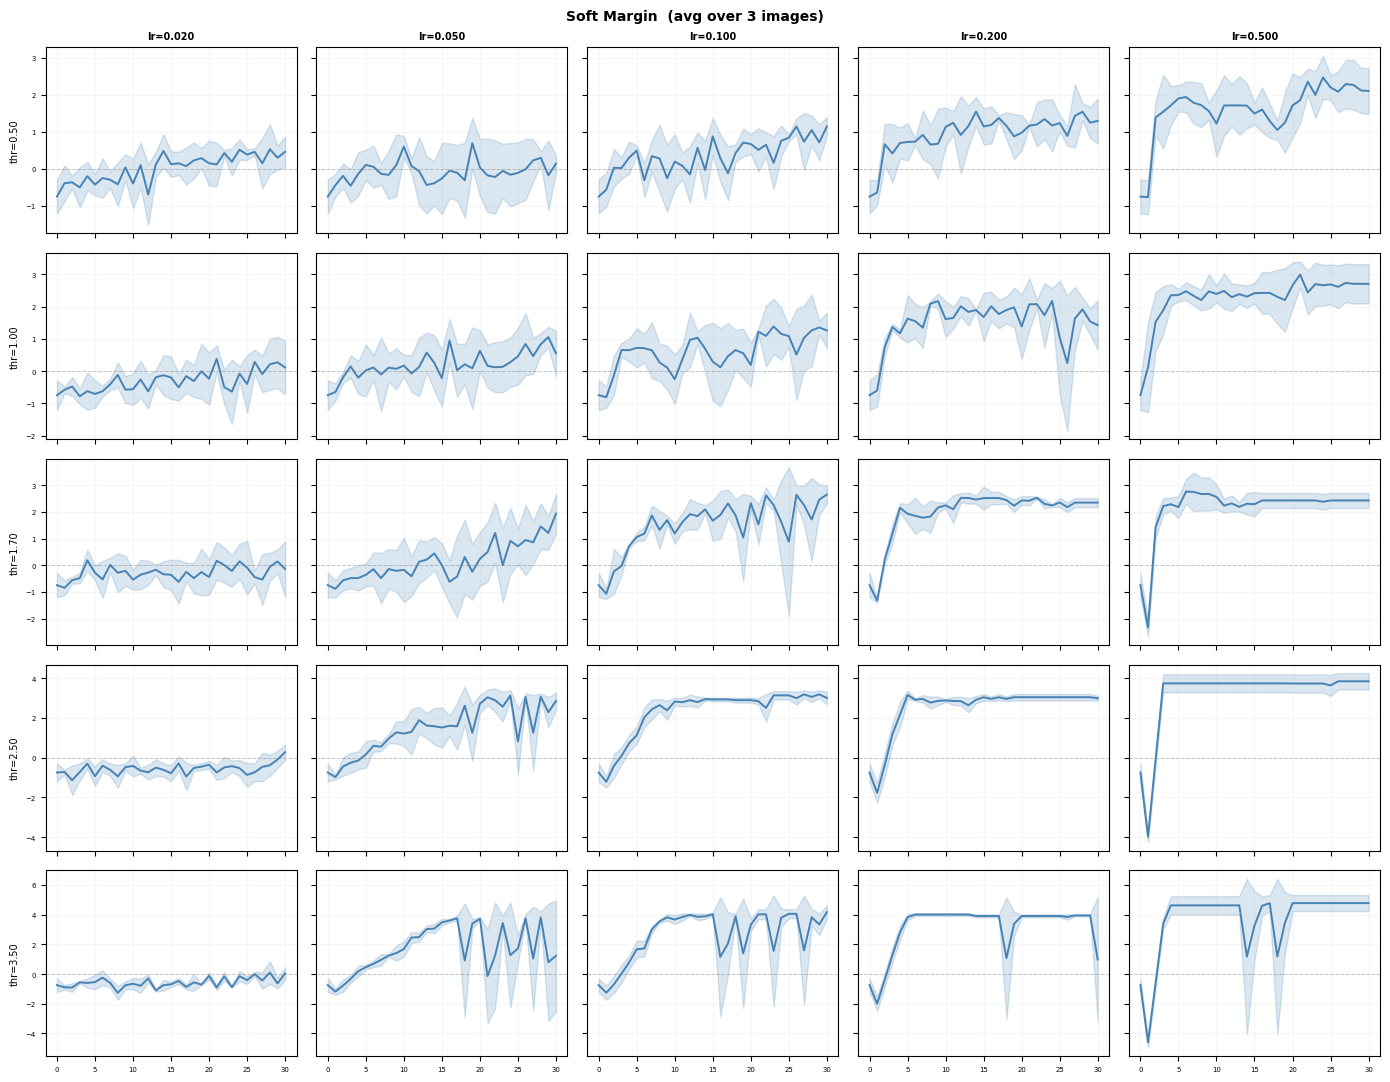

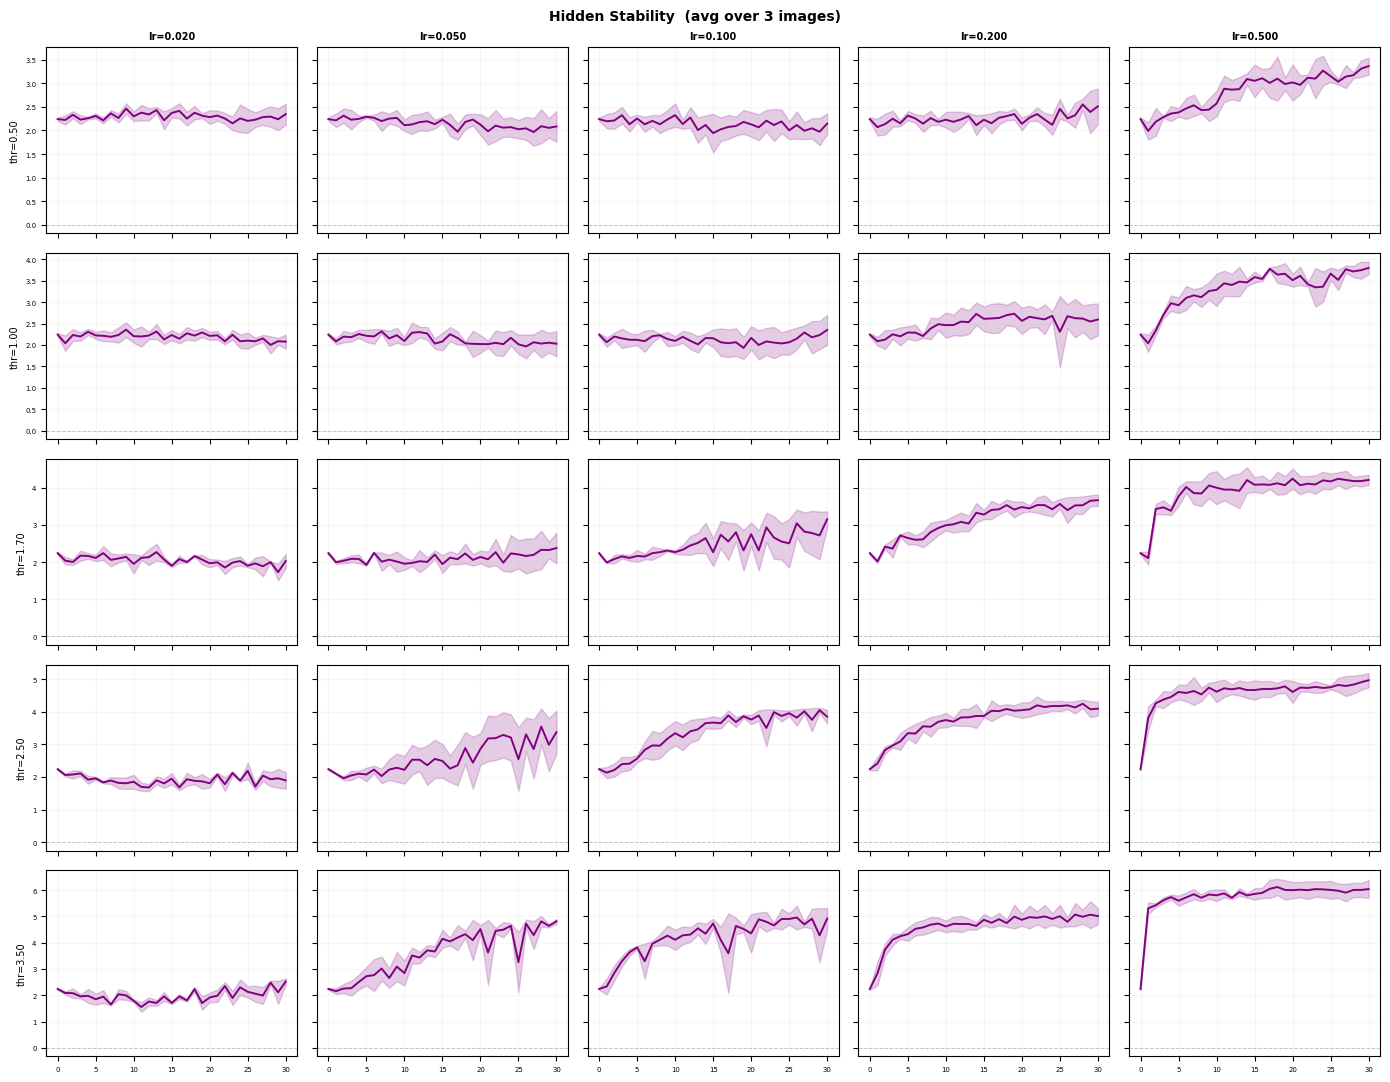

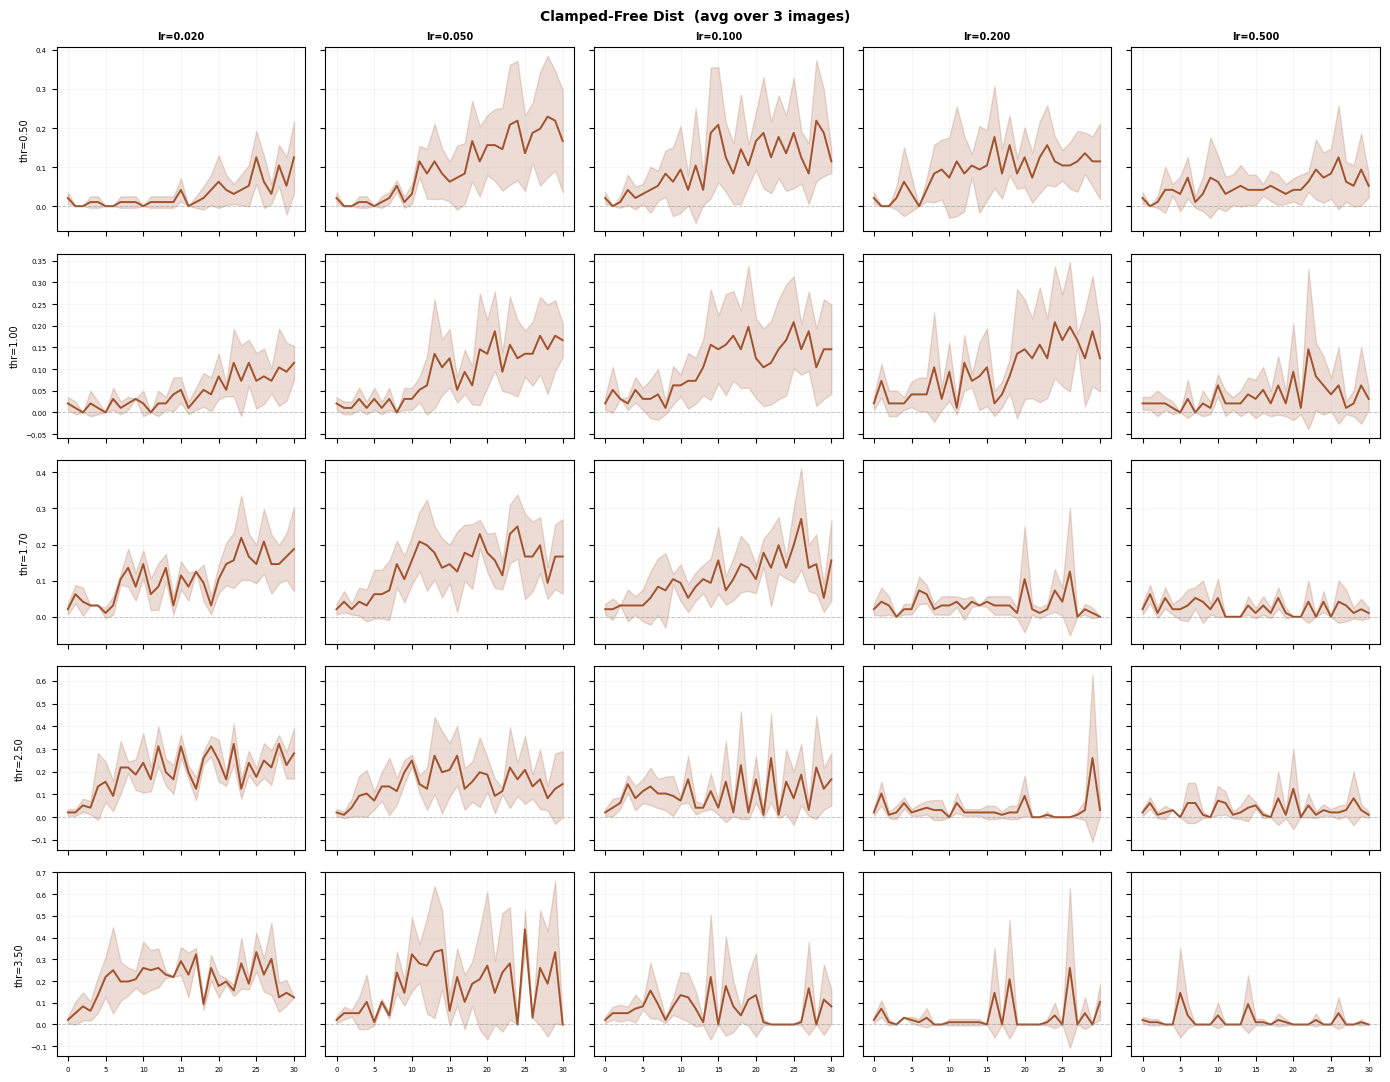

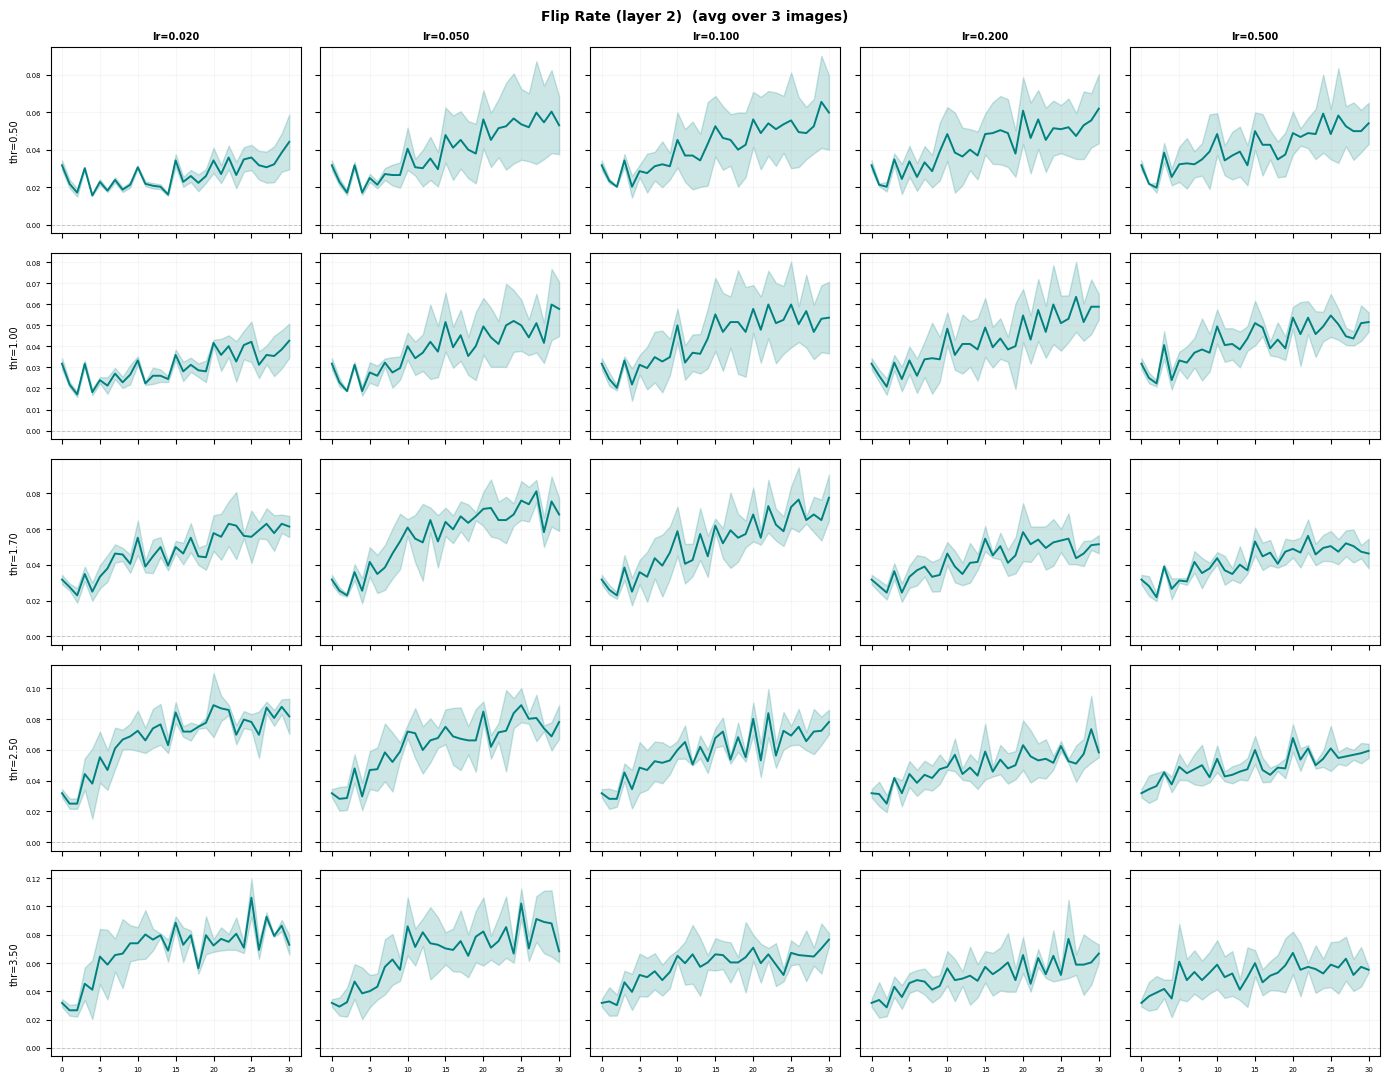

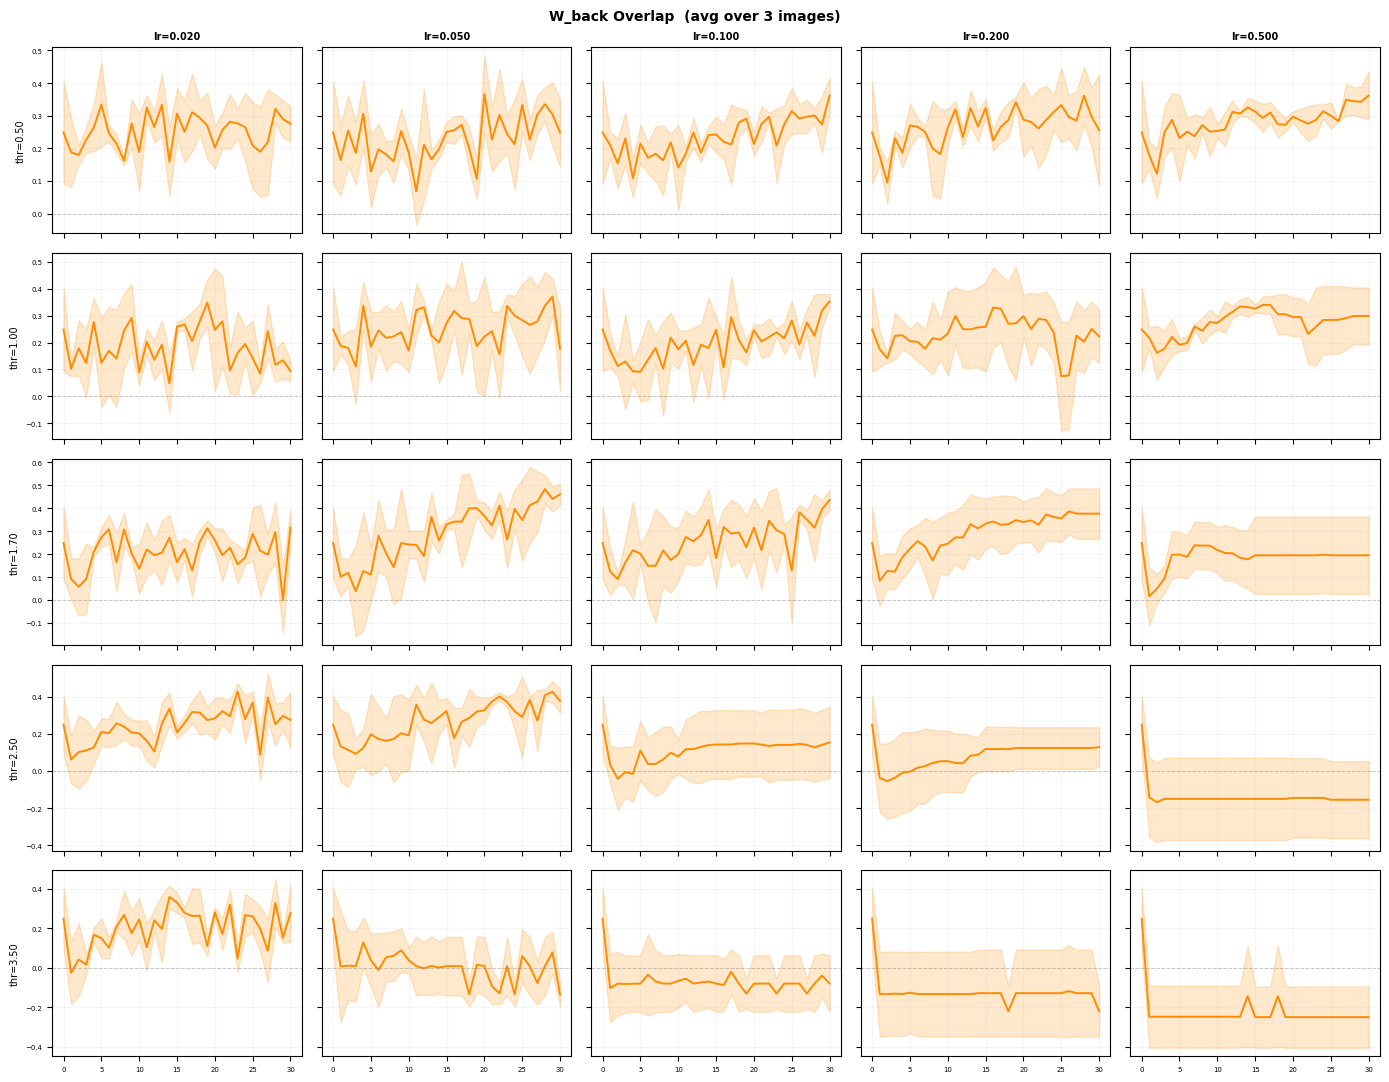

In [23]:
_METRIC_LABELS = {
    "soft_margin":      ("Soft Margin",        "steelblue"),
    "hidden_stability": ("Hidden Stability",   "purple"),
    "cf_dist":          ("Clamped-Free Dist",  "sienna"),
    "flip_rate":        ("Flip Rate (layer 2)","teal"),
    "wback_overlap":    ("W_back Overlap",     "darkorange"),
}


def plot_metric_grid(sweep: dict, metric: str, thresholds=None, lrs=None,
                     n_updates=None, title_prefix=""):
    """Plot a (n_thr × n_lr) grid of memorization curves for one metric."""
    if thresholds is None: thresholds = THRESHOLDS
    if lrs        is None: lrs        = LRS
    if n_updates  is None: n_updates  = N_UPDATES

    label, color = _METRIC_LABELS[metric]
    n_thr, n_lr  = len(thresholds), len(lrs)
    steps        = np.arange(n_updates + 1)

    fig, axes = plt.subplots(n_thr, n_lr, figsize=(2.8 * n_lr, 2.2 * n_thr),
                              sharex=True, sharey="row")
    for r, thr in enumerate(thresholds):
        for c, lr in enumerate(lrs):
            ax   = axes[r, c]
            cell = sweep[(thr, lr)]
            mean = cell[metric]["mean"]
            std  = cell[metric]["std"]

            ax.plot(steps, mean, color=color, lw=1.4)
            ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.2)
            ax.axhline(0, color="gray", lw=0.7, ls="--", alpha=0.4)

            ax.tick_params(labelsize=5)
            ax.grid(True, alpha=0.1)

            if r == 0:
                ax.set_title(f"lr={lr:.3f}", fontsize=7, fontweight="bold")
            if c == 0:
                ax.set_ylabel(f"thr={thr:.2f}", fontsize=7)

    fig.suptitle(f"{title_prefix}{label}  (avg over {len(IMG_INDICES)} images)",
                 fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.show()


# ── Plot all 5 metrics ─────────────────────────────────────────────────
for metric_key in _METRIC_LABELS:
    plot_metric_grid(sweep, metric_key)


## Forgetting

In [24]:
# ── Forgetting protocol config ─────────────────────────────────────────
N_LEARN_A = 20   # weight updates in phase A (memorize A)
N_LEARN_B = 20   # weight updates in phase B (memorize B, watching A)

# Image pairs: (idx_a, idx_b) — one pair per run, averaged over pairs
IMG_PAIRS = [(0, 1), (2, 3), (4, 5)]

print(f"N_LEARN_A={N_LEARN_A}  N_LEARN_B={N_LEARN_B}")
print("Image pairs:")
for ia, ib in IMG_PAIRS:
    la = int(np.array(y[ia]).argmax())
    lb = int(np.array(y[ib]).argmax())
    print(f"  ({ia},{ib})  label A={la}  label B={lb}")


def _eval_metrics(orch, st, x_in, y_in, rng):
    """Run dynamics and compute all 5 metrics. Returns (metrics_dict, rng)."""
    s0 = st.init(x_in, y_in)
    rng, dyn_rng = jax.random.split(rng)
    sf, history  = run_dynamics(orch, s0, rng=dyn_rng)

    sm, rng = _soft_margin(orch, sf, x_in, y_in, rng)
    hs      = _hidden_stability(orch, sf)
    cd      = _clamped_free_dist(history, layer_idx=2)
    fr      = _flip_rate(history, layer_idx=2)
    wo      = _wback_overlap(orch, sf)

    return {"soft_margin": sm, "hidden_stability": hs,
            "cf_dist": cd, "flip_rate": fr, "wback_overlap": wo}, rng


def run_forgetting(
    x_a, y_a, x_b, y_b,
    threshold: float,
    lr: float,
    seed: int = 0,
    n_learn_a: int = None,
    n_learn_b: int = None,
) -> dict:
    """A→B forgetting trial, tracking all 5 internal metrics.

    Phase A: train on A for n_learn_a steps, evaluate only A.
    Phase B: train on B for n_learn_b steps, evaluate BOTH A and B.

    Returns
    -------
    dict with:
      'phase_a'   : dict of metric → list[float]  (n_learn_a + 1 steps)
      'phase_b_a' : dict of metric → list[float]  (n_learn_b + 1 steps)  ← A during B training
      'phase_b_b' : dict of metric → list[float]  (n_learn_b + 1 steps)  ← B during B training
    """
    if n_learn_a is None: n_learn_a = N_LEARN_A
    if n_learn_b is None: n_learn_b = N_LEARN_B

    st, orch = build_model(seed=seed, threshold=threshold)
    optimizer, opt_state = build_optimizer(orch, lr=lr)
    rng = jax.random.PRNGKey(seed)

    _mk = lambda: {k: [] for k in
                   ["soft_margin", "hidden_stability", "cf_dist", "flip_rate", "wback_overlap"]}

    phase_a   = _mk()
    phase_b_a = _mk()
    phase_b_b = _mk()

    # ── Phase A ───────────────────────────────────────────────────────
    for step in range(n_learn_a + 1):
        m, rng = _eval_metrics(orch, st, x_a, y_a, rng)
        for k, v in m.items():
            phase_a[k].append(v)

        if step < n_learn_a:
            s0 = st.init(x_a, y_a)
            rng, dyn_rng = jax.random.split(rng)
            sf, _ = run_dynamics(orch, s0, rng=dyn_rng)
            rng, upd_rng = jax.random.split(rng)
            orch, opt_state = apply_update(orch, sf, upd_rng, optimizer, opt_state)

    # ── Phase B ───────────────────────────────────────────────────────
    for step in range(n_learn_b + 1):
        m_a, rng = _eval_metrics(orch, st, x_a, y_a, rng)
        m_b, rng = _eval_metrics(orch, st, x_b, y_b, rng)
        for k in m_a:
            phase_b_a[k].append(m_a[k])
            phase_b_b[k].append(m_b[k])

        if step < n_learn_b:
            s0 = st.init(x_b, y_b)
            rng, dyn_rng = jax.random.split(rng)
            sf, _ = run_dynamics(orch, s0, rng=dyn_rng)
            rng, upd_rng = jax.random.split(rng)
            orch, opt_state = apply_update(orch, sf, upd_rng, optimizer, opt_state)

    return {"phase_a": phase_a, "phase_b_a": phase_b_a, "phase_b_b": phase_b_b}


def average_forgetting_runs(runs: list[dict]) -> dict:
    """Average a list of forgetting trial dicts → mean + std for each phase/metric."""
    out = {}
    for phase_key in ("phase_a", "phase_b_a", "phase_b_b"):
        out[phase_key] = {}
        metric_keys = runs[0][phase_key].keys()
        for mk in metric_keys:
            arr = np.array([r[phase_key][mk] for r in runs], dtype=float)
            out[phase_key][mk] = {"mean": arr.mean(axis=0), "std": arr.std(axis=0)}
    return out


def sweep_forgetting(
    thresholds: list = None,
    lrs: list = None,
    img_pairs: list = None,
    x_data=None,
    y_data=None,
    n_learn_a: int = None,
    n_learn_b: int = None,
    seed: int = 0,
    verbose: bool = True,
) -> dict:
    """Sweep (threshold × lr), averaging over img_pairs.

    Returns
    -------
    sweep_f : dict  (thr, lr) → averaged forgetting trial dict
    """
    if thresholds is None: thresholds = THRESHOLDS
    if lrs        is None: lrs        = LRS
    if img_pairs  is None: img_pairs  = IMG_PAIRS
    if x_data     is None: x_data     = x
    if y_data     is None: y_data     = y
    if n_learn_a  is None: n_learn_a  = N_LEARN_A
    if n_learn_b  is None: n_learn_b  = N_LEARN_B

    sweep_f = {}
    for thr in thresholds:
        for lr in lrs:
            runs = [
                run_forgetting(
                    x_data[ia:ia+1], y_data[ia:ia+1],
                    x_data[ib:ib+1], y_data[ib:ib+1],
                    threshold=thr, lr=lr, seed=seed,
                    n_learn_a=n_learn_a, n_learn_b=n_learn_b,
                )
                for ia, ib in img_pairs
            ]
            sweep_f[(thr, lr)] = average_forgetting_runs(runs)
        if verbose:
            print(f"  thr={thr:.2f} done")
    return sweep_f


N_LEARN_A=20  N_LEARN_B=20
Image pairs:
  (0,1)  label A=3  label B=2
  (2,3)  label A=5  label B=7
  (4,5)  label A=2  label B=8


In [25]:
print("Running forgetting sweep ...")
sweep_f = sweep_forgetting(verbose=True)
print("Done.")


Running forgetting sweep ...
  thr=0.50 done
  thr=1.00 done
  thr=1.70 done
  thr=2.50 done
  thr=3.50 done
Done.


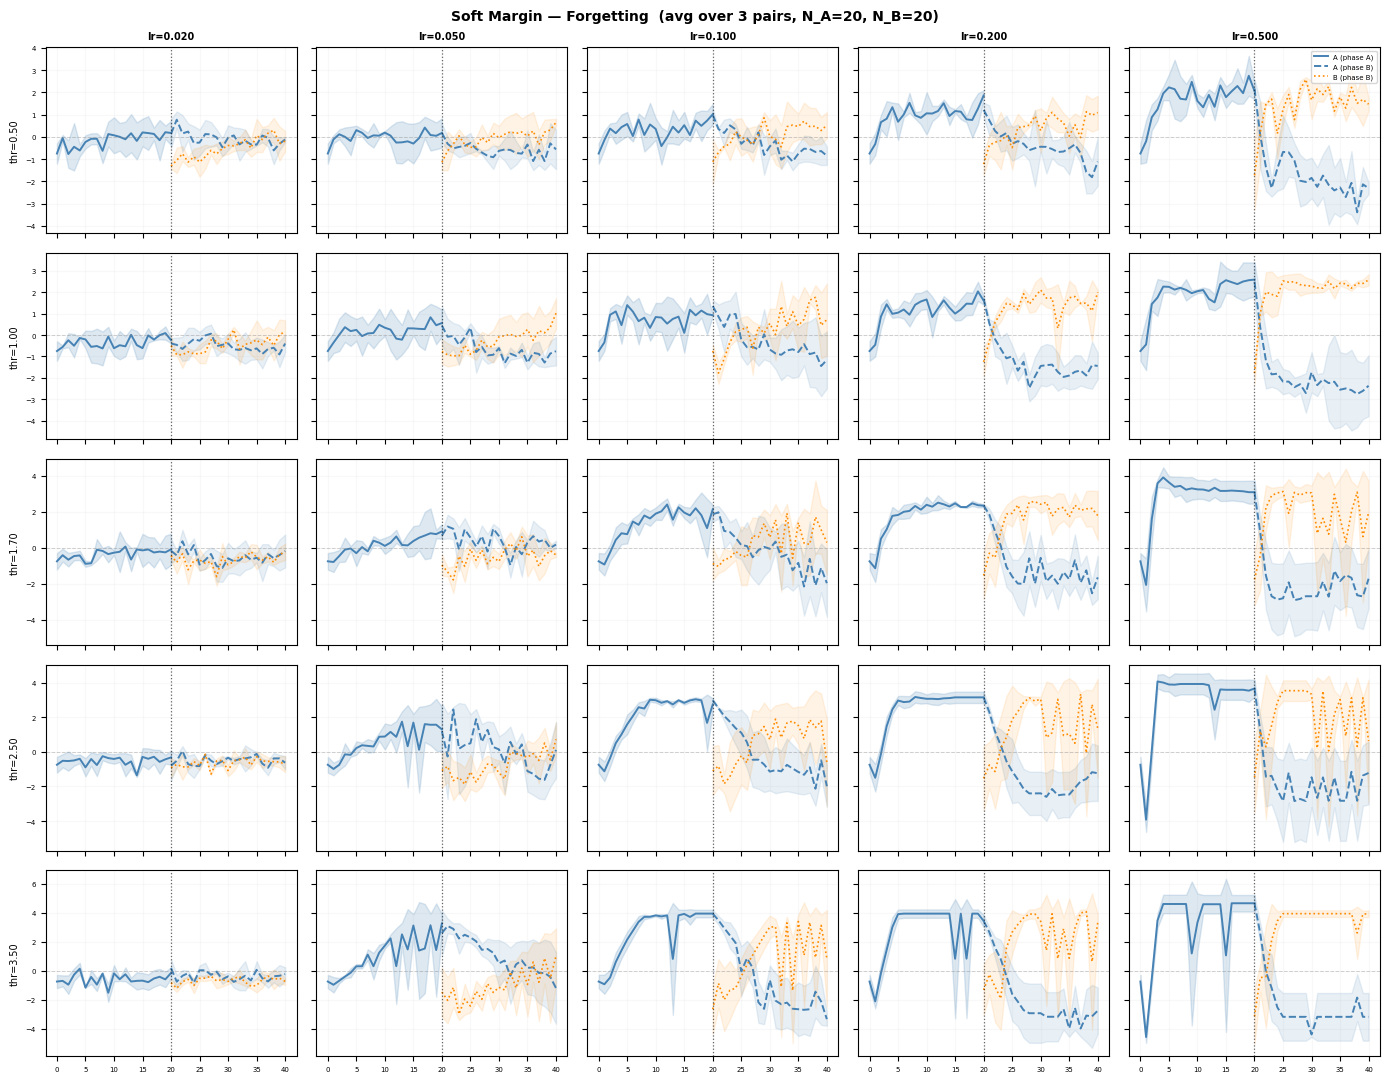

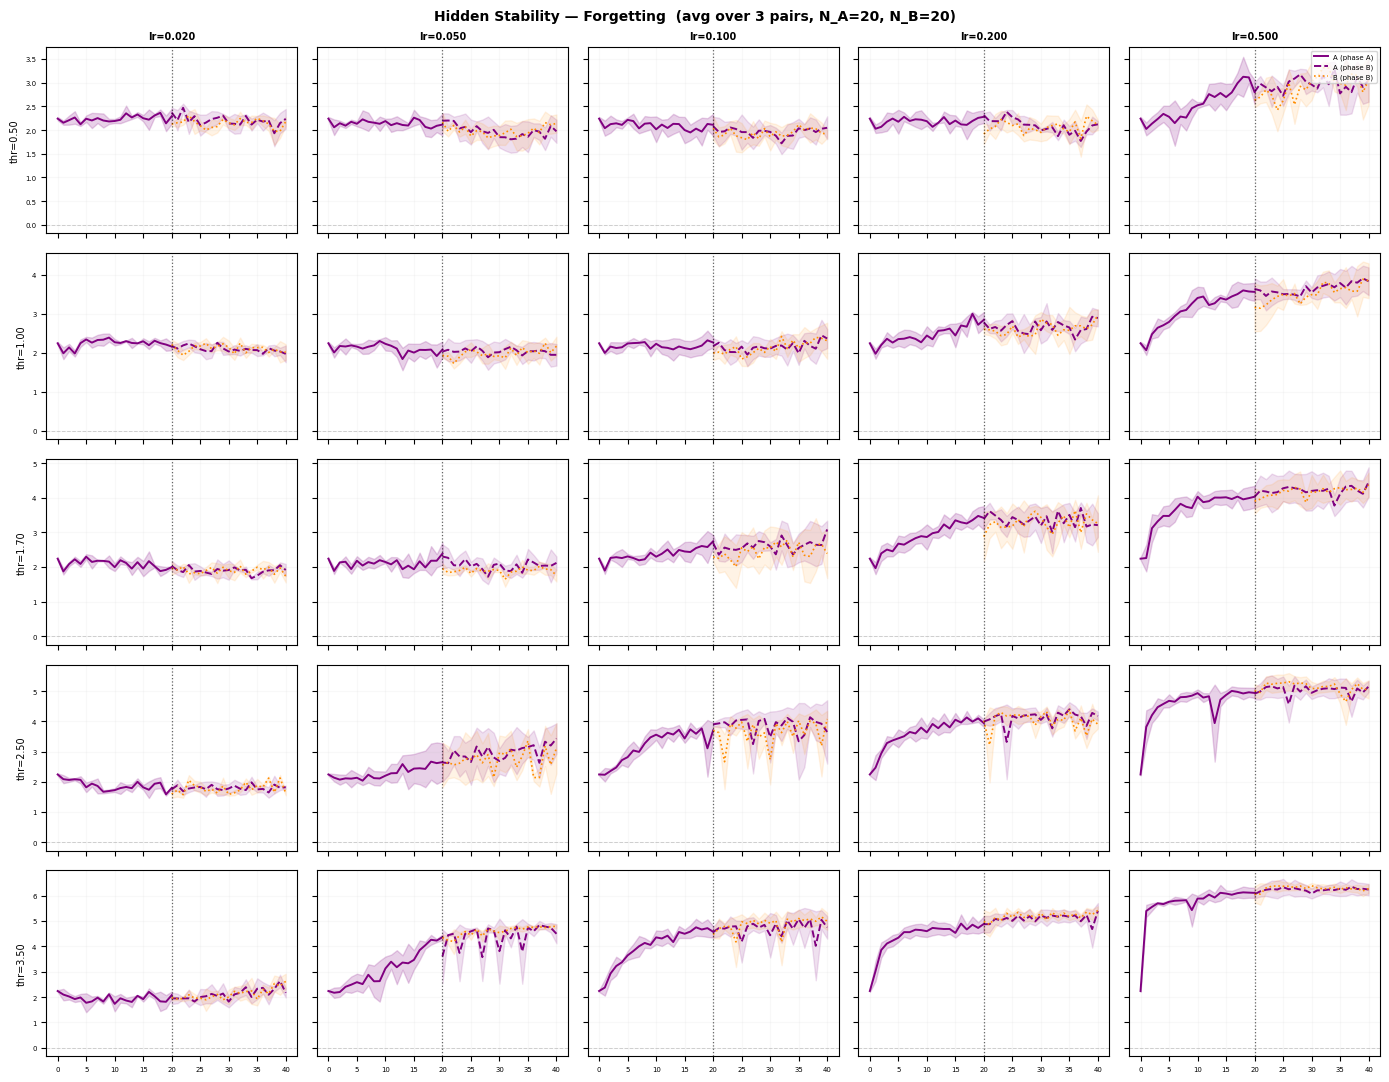

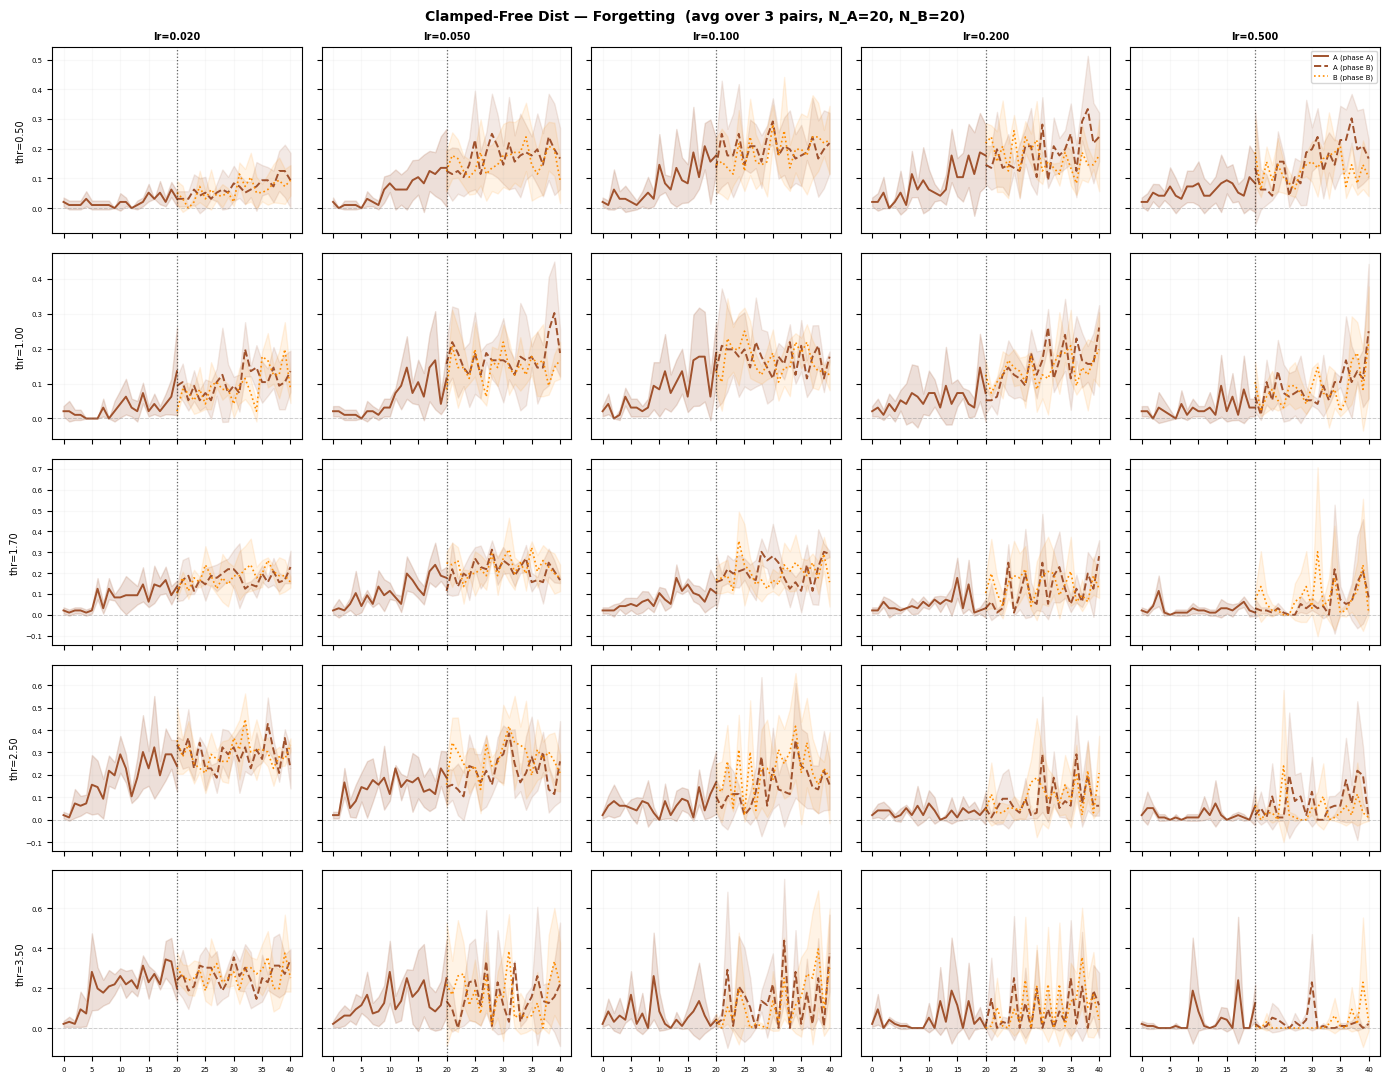

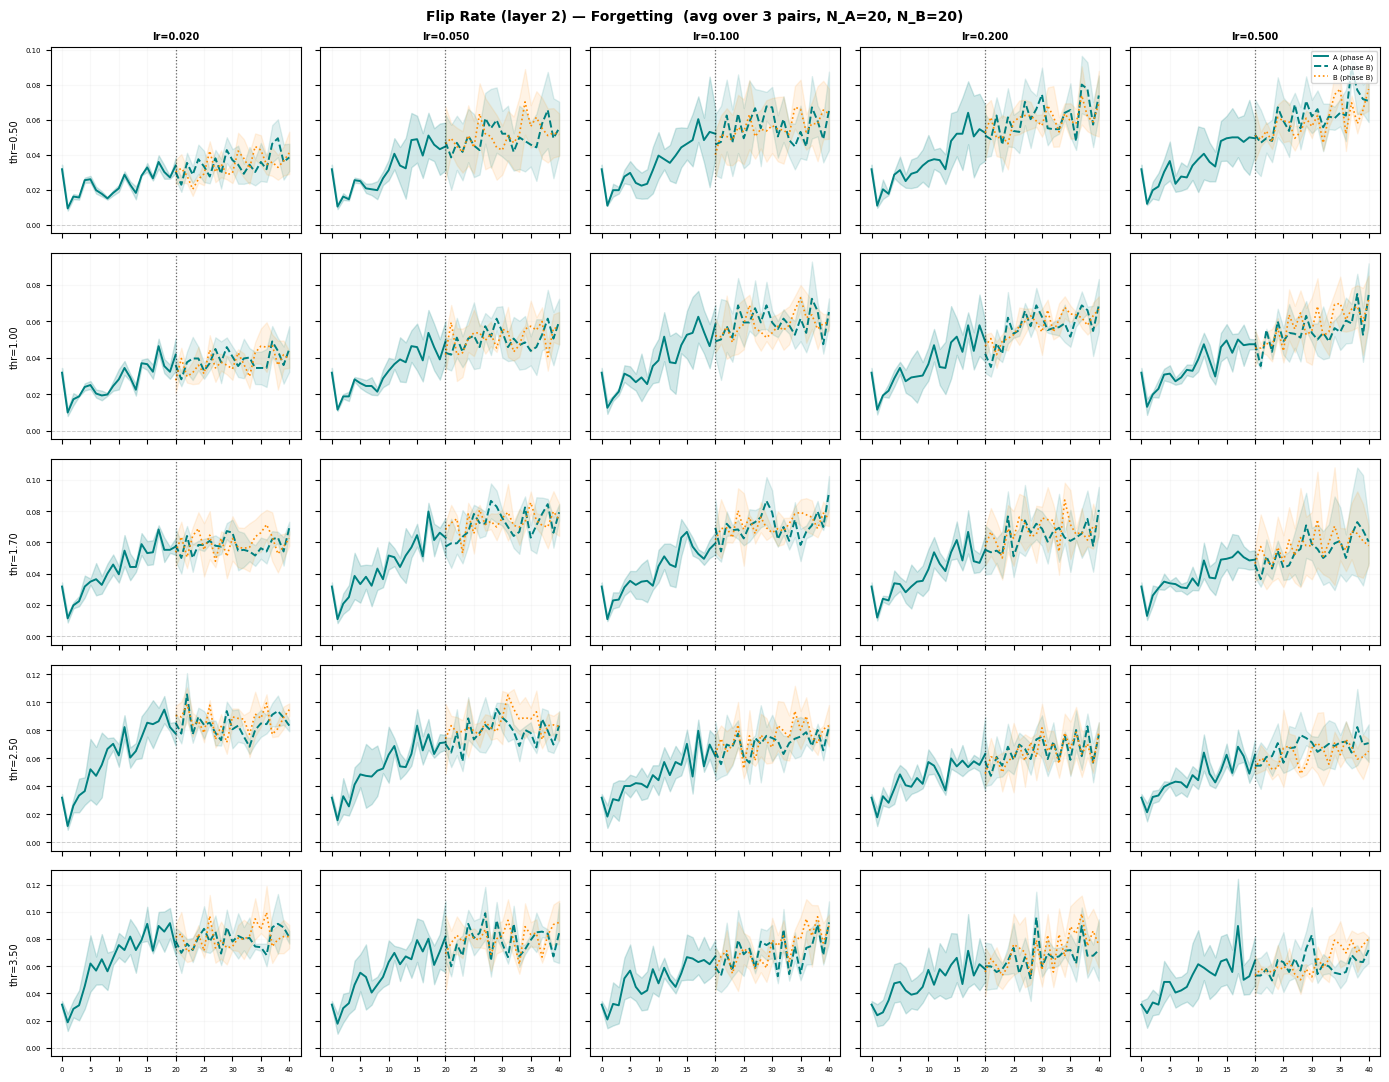

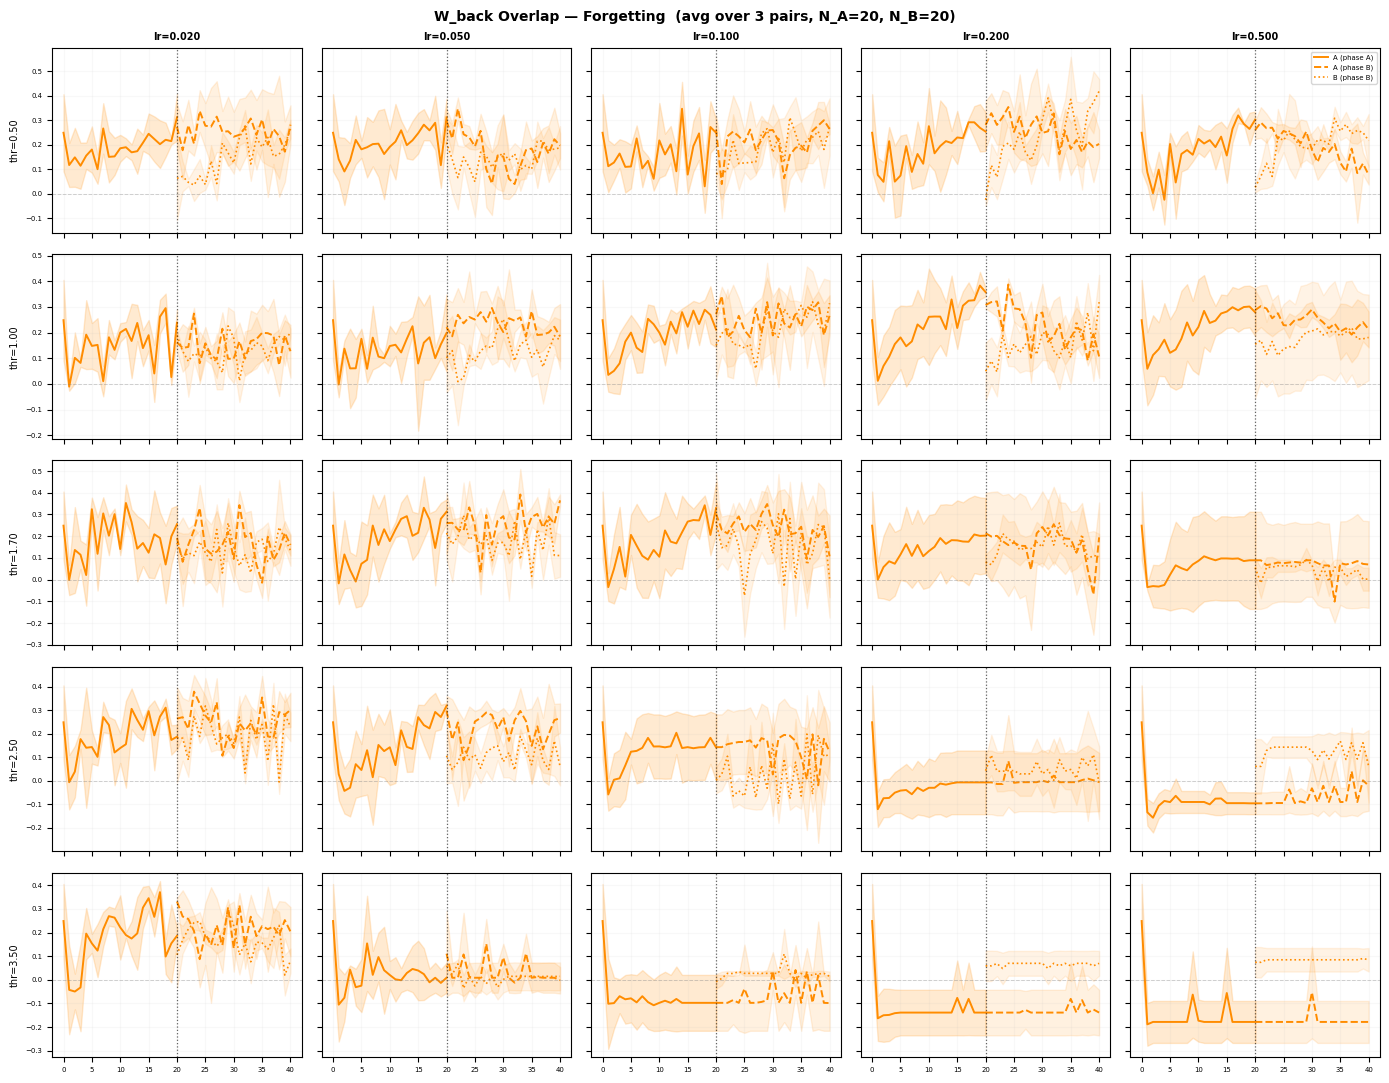

In [26]:
def plot_forgetting_metric_grid(
    sweep_f: dict,
    metric: str,
    thresholds: list = None,
    lrs: list = None,
    n_learn_a: int = None,
    n_learn_b: int = None,
    show_b: bool = True,
):
    """Grid of concatenated A→B trajectory plots for one metric.

    Each cell shows:
      solid blue   — image A metric during Phase A (A being memorized)
      dashed blue  — image A metric during Phase B (B being memorized) ← the forgetting view
      dotted orange — image B metric during Phase B (optional, show_b=True)
    A vertical black dotted line marks the phase boundary.
    """
    if thresholds is None: thresholds = THRESHOLDS
    if lrs        is None: lrs        = LRS
    if n_learn_a  is None: n_learn_a  = N_LEARN_A
    if n_learn_b  is None: n_learn_b  = N_LEARN_B

    label, color = _METRIC_LABELS[metric]
    n_thr, n_lr  = len(thresholds), len(lrs)

    steps_a = np.arange(n_learn_a + 1)
    # phase B x-axis continues from the last phase-A step
    steps_b = np.arange(n_learn_a, n_learn_a + n_learn_b + 1)
    boundary = n_learn_a

    fig, axes = plt.subplots(n_thr, n_lr, figsize=(2.8 * n_lr, 2.2 * n_thr),
                              sharex=True, sharey="row")

    for r, thr in enumerate(thresholds):
        for c, lr in enumerate(lrs):
            ax   = axes[r, c]
            cell = sweep_f[(thr, lr)]

            # ── Phase A: A's metric ──────────────────────────────────
            m_pa = cell["phase_a"][metric]["mean"]
            s_pa = cell["phase_a"][metric]["std"]
            ax.plot(steps_a, m_pa, color=color, lw=1.4, ls="-", label="A (phase A)")
            ax.fill_between(steps_a, m_pa - s_pa, m_pa + s_pa, color=color, alpha=0.18)

            # ── Phase B: A's metric (forgetting) ──────────────────────
            m_ba = cell["phase_b_a"][metric]["mean"]
            s_ba = cell["phase_b_a"][metric]["std"]
            ax.plot(steps_b, m_ba, color=color, lw=1.4, ls="--", label="A (phase B)")
            ax.fill_between(steps_b, m_ba - s_ba, m_ba + s_ba, color=color, alpha=0.12)

            # ── Phase B: B's metric ───────────────────────────────────
            if show_b:
                m_bb = cell["phase_b_b"][metric]["mean"]
                s_bb = cell["phase_b_b"][metric]["std"]
                ax.plot(steps_b, m_bb, color="darkorange", lw=1.2, ls=":",
                        label="B (phase B)")
                ax.fill_between(steps_b, m_bb - s_bb, m_bb + s_bb,
                                color="darkorange", alpha=0.10)

            # ── Phase boundary + zero line ────────────────────────────
            ax.axvline(boundary, color="black", lw=0.9, ls=":", alpha=0.6)
            ax.axhline(0, color="gray", lw=0.7, ls="--", alpha=0.35)

            ax.tick_params(labelsize=5)
            ax.grid(True, alpha=0.08)

            if r == 0:
                ax.set_title(f"lr={lr:.3f}", fontsize=7, fontweight="bold")
            if c == 0:
                ax.set_ylabel(f"thr={thr:.2f}", fontsize=7)
            if r == 0 and c == n_lr - 1:
                ax.legend(fontsize=5, loc="upper right")

    fig.suptitle(
        f"{label} — Forgetting  "
        f"(avg over {len(IMG_PAIRS)} pairs, N_A={n_learn_a}, N_B={n_learn_b})",
        fontsize=10, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


# ── Plot all 5 metrics for the forgetting sweep ────────────────────────
for metric_key in _METRIC_LABELS:
    plot_forgetting_metric_grid(sweep_f, metric_key)
